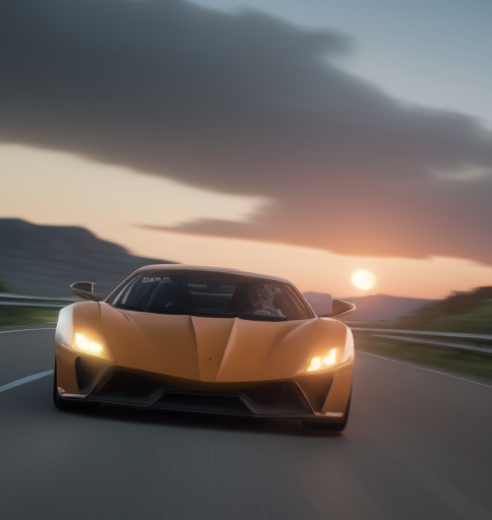

In [1]:
from urllib.request import urlopen
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")
image

In [2]:
prompt = "Question: Write down what you see in this picture. Answer:"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [ ]:
dtype = torch.float16 if device == "cuda" else torch.float32
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=dtype)
model.to(device)
blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [11]:
inputs = blip_processor(images=image, text=prompt, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)

generated_text = generated_text[0].strip()
generated_text

'a yellow sports car driving down a road'

In [13]:
prompt = "Question: Write down what you see in this picture. Answer: A sportscar driving on the road at sunset. Question: What would it cost me to drive that car? Answer:"

inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)

generated_text = generated_text[0].strip()
generated_text

'question : write down what you see in this picture. answer : a sportscar driving on the road at sunset. question : what would it cost me to drive that car? answer :'

In [ ]:
from IPython.display import HTML, display
import ipywidgets as widgets

memory=[]
output = widgets.Output()

def text_eventhandler(*args):
    question = args[0]["new"]

    if question:
        args[0]["owner"].value = ""

    if not memory:
        prompt = " Question: " + question + " Answer:"
    else:
        template = "Question:  {} Answer: {}"
        prompt = " ".join(
            [
                template.format(memory[i][0], memory[i][1])
                for i in range(len(memory))
            ]
        ) + " Question: " + question + " Answer:"

    inputs = blip_processor(image, text=prompt, return_tensors="pt")
    inputs = inputs.to(device, torch.float16)

    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = blip_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )

    generated_text = generated_text[0].strip().split("Question")[0]

    memory.append((question, generated_text))

    output.append_display_data(HTML("<b>USER:</b> " + question))
    output.append_display_data(HTML("<b>BLIP-2:</b> " + generated_text))
    output.append_display_data(HTML("<br>"))

in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, "value")


display(
    widgets.VBox(
        children=[output, in_text],
        layout=widgets.Layout(display="inline-flex", flex_flow="column-reverse")
    )
)

